# Physics Informed Neural Network (PINN) for Advection-diffusion Model in Porous Materials

**Date:** March 13th, 2026

The advection-diffusion-reaction equation is given by:

$$
\beta \frac{\partial u}{\partial t} + \nabla \cdot (V u - D \nabla u) = \sigma (u),
$$ 

where $\beta$ is the porosity term, $V$ is the Darcy velocity, $D$ is the dispersion/diffusion term and $\sigma (u)$ is a non-linear function of the concentration.

In [2]:
# import libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from keras import layers
from keras.constraints import NonNeg
from keras.regularizers import l1_l2
from time import time
import matplotlib.pyplot as plt
import os

2026-03-31 22:58:38.206283: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-31 22:58:38.783796: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-31 22:58:41.399311: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
# Input parameters
tol = 1e-8 # Tolerance for convergence

# Data
test_case = "testcase0" # testcase
data_file = "data/" + test_case
coarsen_data = 1 # Coarsen data by this factor
data_perturbation = 0.e-2 # Perturb data 

# Training parameters
train_parameters = True
nparm = 1 # Number of parameters to train (d, u, beta0s)
param_perturbation = 1.2 # Perturb parameters by this factor
learning_rate_param = 2.e-1 # Learning rate for the parameters
train_parameters_epoch = 1000 # Number of epochs to train the parameters

# Loss function weigths
pde_weight = 1.      # penalty for the PDE
data_weight = 1.     # penalty for the data fitting (will be multiplied by param_data_factor)
ic_weight = 10.    # penalty for the initial condition
bc_weight = 10.     # penalty for the boundary condition

# Parameters for the neural network (NN)
epochs = 5000 # Number of epochs to train the NN
epoch_print = 10 # number fo epochs to print the training progress

learning_rate_val = 1e-2 # Learning rate for the NN
learning_rate_decay_factor = 0.98 # Learning rate decay factor
learning_rate_step = 100 # Learning rate decay step

num_hidden_layers = 8 # Number of hidden layers in the NN
num_neurons = 20 # Number of neurons in each hidden layer
num_neurons_layer = num_neurons # The same number of neurons in each hidden layer

activation = "tanh" # Activation function for the hidden layers
reaction_model = "michaelis-menten" # Reaction model (arrhenius, polynomial, etc.)

In [4]:
# Create the learning rate scheduler
epochs_array = np.arange(learning_rate_step, epochs + learning_rate_step, learning_rate_step)
decay_steps = np.array([learning_rate_val*learning_rate_decay_factor**i 
                        for i in range(int(epochs/learning_rate_step)+1)])

learning_rate = keras.optimizers.schedules.PiecewiseConstantDecay(
                    boundaries=epochs_array, values=decay_steps)

In [5]:
# Open de data file

# Check if the data directory exists
if os.path.exists(data_file):
    print(f"Data directory '{data_file}' exists.")
else:
    print(f"Data directory '{data_file}' not found. Please check the path and filename.")

# Load the data 
try:
    p = pd.read_csv(data_file + "/p.csv", header=None).values # Parameters array
    x_grid = pd.read_csv(data_file + "/x.csv", header=None) # Spatial grid
    t_grid = pd.read_csv(data_file + "/t.csv", header=None) # Temporal grid
    c_data = pd.read_csv(data_file + "/c.csv", header=None) # Solution array
    
except FileNotFoundError:
    print(f"One or more data files for test case '{test_case}' not found. Please check the paths and filenames.")

Data directory 'data/testcase0' exists.


In [6]:
# Grid sizes
nx = x_grid.shape[0]
nt = t_grid.shape[0]

# Perturb the data 
c_data = c_data * (1 + data_perturbation * np.random.randn(c_data.size).reshape(c_data.shape))

# 2D data array
c_data_2d = np.reshape(c_data, (nt, nx))

In [7]:
# Coarsen data if needed
if coarsen_data > 1:

    # New rows and columns for coarsened data
    rows = np.r_[0:nt:coarsen_data, nt-1]
    cols = np.r_[0:nx:coarsen_data, nx-1]

    # Coarsen the grid
    x_grid = x_grid.iloc[cols]
    t_grid = t_grid.iloc[rows]

    # Coarsen the data
    c_data_2d = c_data_2d[np.ix_(rows, cols)]
    c_data = c_data_2d.ravel()

In [8]:
# Mesh and time discretization
nt = t_grid.shape[0]
nx = x_grid.shape[0]
X_grid, T_grid = np.meshgrid(x_grid, t_grid)

# Conver the data to numpy arrays
p = np.array(p).squeeze().astype(np.float32)
x_data = np.array(X_grid, dtype=np.float32).flatten()
t_data = np.array(T_grid, dtype=np.float32).flatten()
c_data = np.array(c_data, dtype=np.float32)

# Data to tensors for TensorFlow
x_tf = tf.expand_dims(tf.convert_to_tensor(x_data), -1)
t_tf = tf.expand_dims(tf.convert_to_tensor(t_data), -1)
c_tf = tf.convert_to_tensor(c_data)

# variables definition for tensorflow
tt = tf.Variable(t_tf, dtype=tf.float32)
xx = tf.Variable(x_tf, dtype=tf.float32)

2026-03-31 22:58:42.987681: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [9]:
# perturb the parameters
randp = (p * param_perturbation ** (np.random.randn(p.size) * 2 - 1)).astype(np.float32)

# Aditional parameters for the model
beta0 = randp[0] # Porosity fixed
d = keras.Variable([randp[1]], dtype = tf.float32, name = "d",
                   trainable = train_parameters)  # Diffusion coefficient
u = keras.Variable([randp[2]], dtype = tf.float32, name = "u", 
                   trainable = (train_parameters and nparm > 1)) # Advection velocity
sigma = keras.Variable([randp[3]], dtype = tf.float32, name = "sigma", 
                       trainable = (train_parameters and nparm > 2)) # Reaction coefficient
params = [d, u, sigma]
params0 = [p[1], p[2], p[3]] # Initial parameters values

# Restore the initial parameters values if not training the parameters
params[nparm:] = params0[nparm:]

# Params names
params_names = ["d", "u", "sigma"]

print(f"Initial parameters: ")
for i in range(nparm):
    print(f"{params_names[i]}: {params0[i]}")

if param_perturbation > 0:
    print(f"\nInitial parameters (perturbed):")

    for i in range(nparm):
        print(f"{params_names[i]}: {randp[i]}")

Initial parameters: 
d: 1.0

Initial parameters (perturbed):
d: 0.6058202385902405


$$
\beta \frac{\partial u}{\partial t} + \nabla \cdot (V u - D \nabla u) = \sigma (u),
$$ 

For the $\sigma (u)$ function concentration we can choose: ```michaelis-menten```, ```linear```, ```quadratic```, and ```polynomial```.

Michaelis-Menten kinetics:

$$
\sigma(u) = \frac{\sigma_1 \times u ^{r_f} }{\sigma_2 + u \times {r_b}}
$$

Linear reaction:

$$
\sigma(u) = \sigma \times u
$$

Quadratic reaction:

$$
\sigma(u) = \sigma \times u^2
$$

Polynomial reaction:

$$
\sigma(u) = \sigma \times u^{r_f} \times (1 - u)^{r_b}
$$

$r_f$ is the forward rate and $r_b$ is the backward rate.

In [10]:
# non-linear reaction term
@tf.function(reduce_retracing=True)
def reaction(c, sigma=sigma, sigma2=1.0e-1, forward_rate=3.0, backward_rate=3.0):
    """ 
    Function reaction term for the PDE. It can be modified to include different reaction models.
        Inputs:
            c(array, float): concentration
            sigma(float): reaction coefficient
            sigma2(float): second reaction coefficient
            forward_rate(float): forward reaction rate
            backward_rate(float): backward reaction rate
        Output:
            reaction term
    """
    if (reaction_model == 'michaelis-menten'):
        return sigma * c**forward_rate / (sigma2 + c**backward_rate) # michaelis-menten kinetics
    elif (reaction_model == 'linear'):
        return sigma * c # linear reaction
    elif (reaction_model == 'quadratic'):
        return sigma * c**2
    elif (reaction_model == 'polynomial'): # Polynomial reaction
        return sigma * c**forward_rate * (1 - c)**backward_rate
    else:
        print('Reaction model not implemented') # Homogeneous reaction (no reaction)
        return 0

In [11]:
# NN construction
def pinn_model(num_hidden_layers=num_hidden_layers, num_neurons_per_layer=num_neurons_layer):
    """
    Function to construct the physics-informed neural network (PINN) model for the advection-diffusion-reaction equation.
        Inputs:
            num_hidden_layers(int): number of hidden layers in the NN
            num_neurons_per_layer(int): number of neurons in each hidden layer
        Output:
            PINN model
    """

    # Create the input layers for the spatial and temporal coordinates
    x_input = keras.Input(shape=(1,))
    t_input = keras.Input(shape=(1,))

    output_c = layers.concatenate([t_input, x_input]) # input layer
    
    # Build the hidden layers
    for i in range(num_hidden_layers):
        output_c = layers.Dense(num_neurons_per_layer,
                                         activation=activation,  
                                         kernel_initializer='glorot_normal',
                                         )(output_c)
    
    # output layer (a single neuron for the concentration)
    output_c = layers.Dense(1)(output_c)

    return keras.Model(inputs=[t_input, x_input], outputs=output_c) # Return the model

In [12]:
@tf.function(reduce_retracing=True)
def custom_loss(inputs, model):

    # Dfine the model inputs
    xx, tt, cc = inputs

    # Compute derivatives
    with tf.GradientTape(persistent=True) as tape:
        # Make the tape watch the input variables
        tape.watch(tt)
        tape.watch(xx)

        # Compute the model output
        output_model = model([tt, xx])

        # Extract the concentration from the model output
        c_model = output_model[:, 0]
        c_model = tf.expand_dims(c_model, -1) # Correct dimentions

        # Derivatives and gradients
        c_x = tape.gradient(c_model, xx)
        c_t = tape.gradient(c_model, tt)
    
    # Second and third term of the PDE
    div_output = u * c_x - d * tape.gradient(c_x, xx)

    del tape

    # Compute the components of loss function
    norm_weight = 1.0 #x_data.max()**2 / (tf.multiply(beta0,d)) # normalization factor for the PDE
    pde_loss = tf.reduce_mean(tf.multiply(norm_weight, (
        (tf.multiply(beta0, c_t) + div_output) ** 2 
        ))) # PDE loss
    data_fitting_loss = tf.reduce_mean((c_model - cc) ** 2) # data misfit
    bc_fitting_loss = tf.reduce_mean((c_model[::nx] - cc[::nx]) ** 2 # dirichlet based on data
                            + (c_x[(nx-1)::nx]) ** 2) # neumann zero
    ic_fitting_loss = tf.reduce_mean((c_model[0:nt] - cc[0:nt])  ** 2) # initial condition based on data
    
    return [pde_loss, data_fitting_loss, ic_fitting_loss, bc_fitting_loss]

In [13]:
# PINN model definition
model = pinn_model(num_hidden_layers=num_hidden_layers, num_neurons_per_layer=num_neurons_layer)

# Trainable variables for the optimizer
trainable = model.trainable_variables 

# Parameters to train
if train_parameters:
    print(f"Training parameters: {params_names[:nparm]}")
    for i in range(nparm):
        trainable.append(params[i])

print(f"\nTotal number of trainable objects: {len(trainable)}")

# Create the optimizer
optimizer = keras.optimizers.Adam(learning_rate=learning_rate, amsgrad=True)

Training parameters: ['d']

Total number of trainable objects: 19


In [14]:
# Create empty lists to store the loss history
losses = np.zeros((epochs, 9)) 
param_values = np.zeros((epochs, nparm))
param_grads = np.zeros((epochs, nparm))
l2_errors = np.zeros((epochs, 1))

In [15]:
# Main loop
stop = False
t0 = time() # Start time
t1 = t0

for epoch in range(epochs):

    # Update the learning rate in function of the epoch
    lr = learning_rate(epoch)

    if train_parameters:
        # tanh transition
        param_data_factor = (np.tanh(10 * (epoch - epochs / 2 - train_parameters_epoch) / epochs) + 1) / 2
        
        # set the parameter to zero for the first epochs
        param_data_factor *= (epoch > train_parameters_epoch) # Set to zero for the first epochs

    else:
        param_data_factor = 1.0
    
    # Compute and normalize the weights for the loss function
    weights = [pde_weight, data_weight*param_data_factor, ic_weight, bc_weight]
    weights = [w/sum(weights) for w in weights]

    # Compute the gradients
    with tf.GradientTape(persistent=True) as tape:

        # Call the tf decorated loss function
        loss0 = custom_loss([xx, tt, c_tf], model) # unweighted loss terms
        loss = [l * w for l, w in zip(loss0, weights)] # weight the losses

        # Append the total loss
        loss.append(sum(loss)) # weighted total loss

    gradients = tape.gradient(loss[-1], trainable)

    del tape
    
    if (train_parameters):
        param_grads[epoch,:] = np.array(gradients[-nparm:]).squeeze()/weights[0] # Store parameter gradients
            
        # Gradients scaling (parameters)
        for i in range(-nparm,0):
            gradients[i] *= learning_rate_param * param_data_factor
    
    # Minimize the gradients (update the model parameters)
    optimizer.apply_gradients(zip(gradients, trainable))    
    
    # Store losses (PDE, data fitting, IC fitting, BC fitting, total loss)
    losses[epoch,:] = np.array(loss0+loss)
    
    # Store the parameters values (v, d, sigma)
    param_values[epoch,:] = np.array(params[:nparm]).squeeze()
    
    # l2 errors
    sol = model([t_data, x_data]).numpy().reshape(nt, nx)
    l2_errors[epoch] = np.linalg.norm(sol - c_data_2d)/np.linalg.norm(c_data_2d)
    
    # Print the results
    if epoch % epoch_print == 0:
        print(f"\nEpoch {epoch + 1}/{epochs},Total loss: {loss[-1].numpy()}")

        # cpu time
        print('CPU time for {} epochs: {} seconds'.format(epoch_print,time() - t1))
        t1 = time()

        # l2 error
        print("l2 space-time relative error: ", l2_errors[epoch])
            
        # parameters
        print(f"param_data_factor = {param_data_factor:.2e}, d = {d.numpy()[0]:.4e}, u = {u.numpy()[0]:.4e}, sigma = {sigma.numpy()[0]:.4e}")
    
    # Check if the loss and the parameters are not decreasing more than a tolerance from the previous epoch
    if epoch > 2*train_parameters_epoch and np.abs(losses[epoch,-1] - losses[epoch-1,-1]) < tol*losses[0,-1] and np.abs(param_values[epoch, 0] - param_values[epoch-1, 0]) < tol*param_values[0,0]:  
        print('Loss is not decreasing anymore. Stopping training.')
        
        break
# Print computation time
print('\nTotal training CPU time: {} seconds'.format(time() - t0))


Epoch 1/5000,Total loss: 0.5345309376716614
CPU time for 10 epochs: 3.027510404586792 seconds
l2 space-time relative error:  [0.24685574]
param_data_factor = 0.00e+00, d = 8.2886e-01, u = 0.0000e+00, sigma = 0.0000e+00

Epoch 11/5000,Total loss: 0.07213141024112701
CPU time for 10 epochs: 2.372187852859497 seconds
l2 space-time relative error:  [0.38087746]
param_data_factor = 0.00e+00, d = 8.2886e-01, u = 0.0000e+00, sigma = 0.0000e+00

Epoch 21/5000,Total loss: 0.028737183660268784
CPU time for 10 epochs: 2.3099238872528076 seconds
l2 space-time relative error:  [0.14890524]
param_data_factor = 0.00e+00, d = 8.2886e-01, u = 0.0000e+00, sigma = 0.0000e+00

Epoch 31/5000,Total loss: 0.02313108555972576
CPU time for 10 epochs: 2.9556448459625244 seconds
l2 space-time relative error:  [0.13408024]
param_data_factor = 0.00e+00, d = 8.2886e-01, u = 0.0000e+00, sigma = 0.0000e+00

Epoch 41/5000,Total loss: 0.019911054521799088
CPU time for 10 epochs: 2.4181578159332275 seconds
l2 space-tim

In [16]:
# Define last epoch
last_epoch = epoch + 1

# Define the style for plotting
import scienceplots
plt.style.use(['science', 'notebook', 'no-latex']) 

In [17]:
# Create output directory if it doesn't exist
output_dir = "output/" + test_case + "/"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Output directory '{output_dir}' created.")
else:
    print(f"Output directory '{output_dir}' already exists.")

Output directory 'output/testcase0/' created.


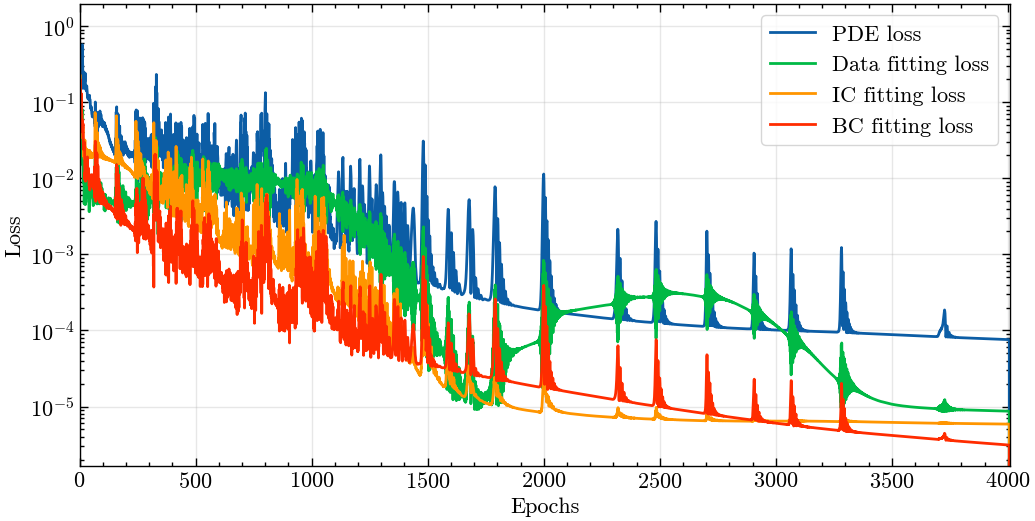

In [19]:
# Plot epochs vs. losses

plt.figure(figsize=(12, 6))
plt.plot(losses[:,0], label='PDE loss')
plt.plot(losses[:,1], label='Data fitting loss')
plt.plot(losses[:,2], label='IC fitting loss')
plt.plot(losses[:,3], label='BC fitting loss')

plt.xlim(0, last_epoch)
# plt.ylim(0, 0.2)

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.legend(frameon = True)

plt.yscale('log')
plt.savefig(output_dir + "/ad-losses.pdf", dpi=300)

plt.show()

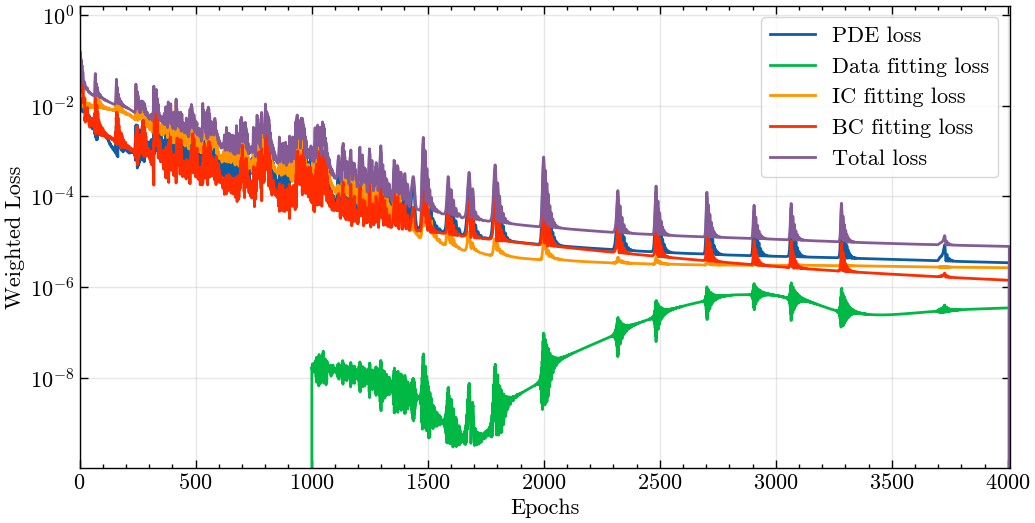

In [20]:
# Plot epochs vs. losses

plt.figure(figsize=(12, 6))
plt.plot(losses[:,4], label='PDE loss')
plt.plot(losses[:,5], label='Data fitting loss')
plt.plot(losses[:,6], label='IC fitting loss')
plt.plot(losses[:,7], label='BC fitting loss')
plt.plot(losses[:,8], label='Total loss')

# Log scale for the loss
plt.yscale('log')

plt.xlim(0, last_epoch)

plt.xlabel('Epochs')
plt.ylabel('Weighted Loss')
plt.grid(alpha=0.3)
plt.legend(frameon = True)

plt.savefig(output_dir + "/ad-losses-weighted.pdf", dpi=300)

plt.show()

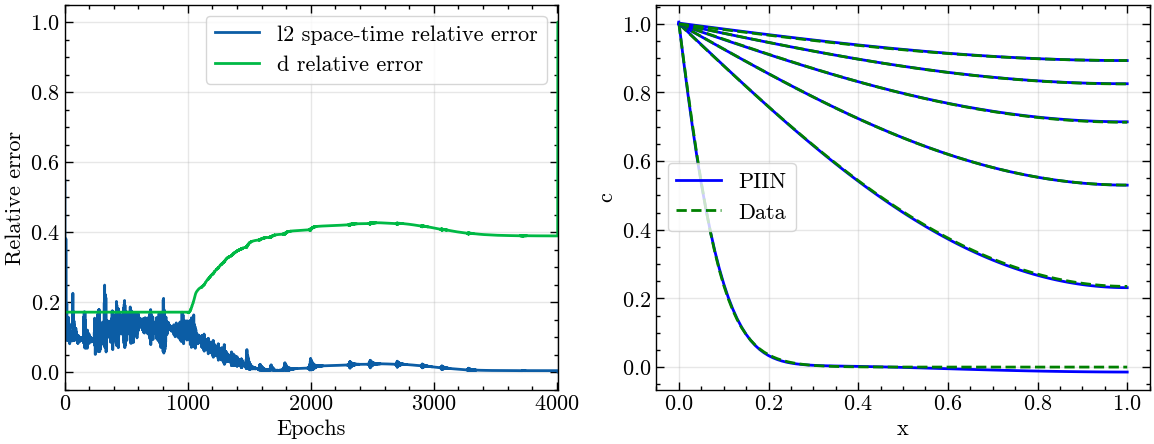

In [21]:
# Create a two panel figure (l2 space-time error and solution model comparison)
plt.subplots(1, 2, figsize=(14, 5))

ax = plt.subplot(1, 2, 1)
# Solution error
ax.plot(l2_errors, label='l2 space-time relative error')
# Parameter error
for i in range(nparm):
    ax.plot(np.abs(param_values[:,i] - params0[i])/params0[i], label=f'{params_names[i]} relative error')

ax.set_xlabel('Epochs')
ax.set_xlim(0, last_epoch)

ax.set_ylabel('Relative error')
ax.grid(alpha=0.3)
ax.legend(frameon = True)

ax = plt.subplot(1, 2, 2)
for i in range(0, sol.shape[0], int(sol.shape[0]/5)):
    ax.plot(x_grid, sol[i,:], label='PIIN' if i == 0 else "", color='blue')
    ax.plot(x_grid, c_data_2d[i,:], label='Data' if i == 0 else "", color='green',  linestyle='dashed')
ax.set_xlabel('x')
ax.set_ylabel('c')
ax.grid(alpha=0.3)
ax.legend(frameon = True)

plt.savefig(output_dir + "/ad-solution-comparison.pdf", dpi=300)

plt.show()


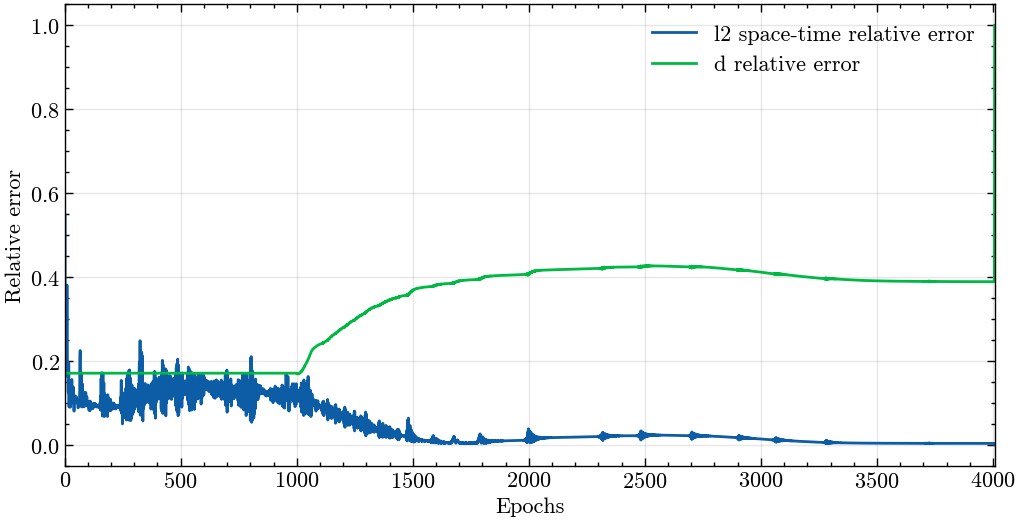

In [22]:
# Plot l2 errors
plt.figure(figsize=(12, 6))

# Solution error
plt.plot(l2_errors, label='l2 space-time relative error')
# Parameter error
for i in range(nparm):
    plt.plot(np.abs(param_values[:,i] - params0[i])/params0[i], label=f'{params_names[i]} relative error')

plt.xlabel('Epochs')
plt.xlim(0, last_epoch)

plt.ylabel('Relative error')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

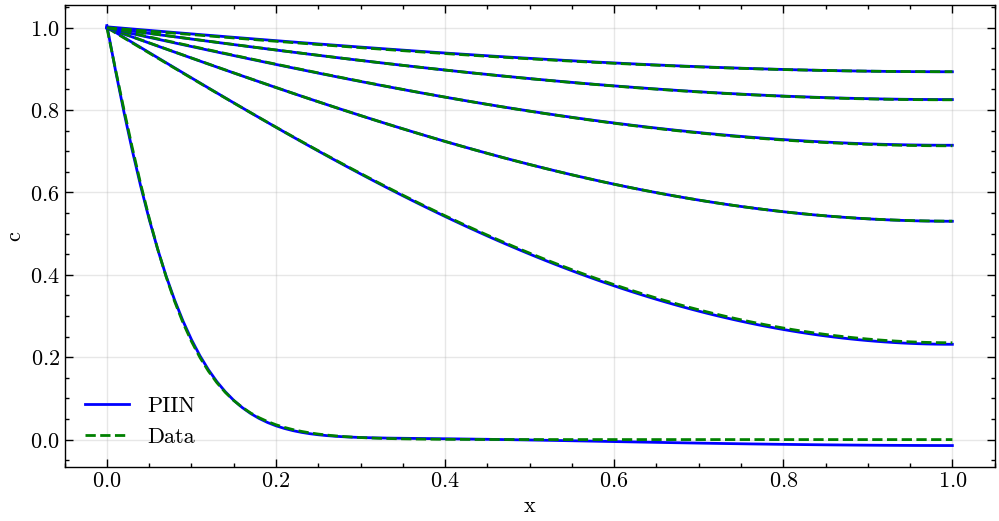

In [23]:
# Plot solutions in space

plt.figure(figsize=(12, 6))

for i in range(0, sol.shape[0], int(sol.shape[0]/5)):
    plt.plot(x_grid, sol[i,:], label='PIIN' if i == 0 else "", color='blue')
    plt.plot(x_grid, c_data_2d[i,:], label='Data' if i == 0 else "", color='green',  linestyle='dashed')
plt.xlabel('x')
plt.ylabel('c')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

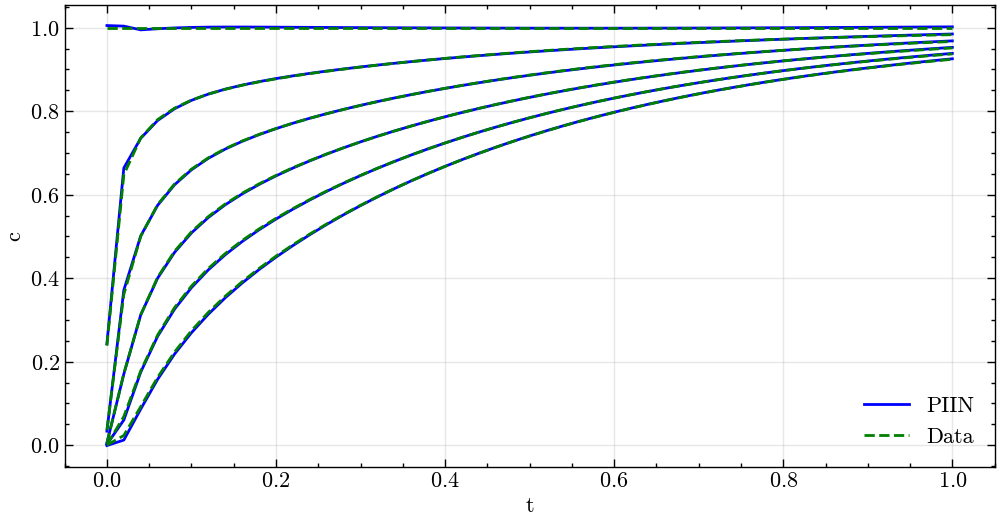

In [24]:
# Plot solutions in space

plt.figure(figsize=(12, 6))

for i in range(0, sol.shape[0], int(sol.shape[0]/5)):
    plt.plot(t_grid, sol[:,i], label='PIIN' if i == 0 else "", color='blue')
    plt.plot(t_grid, c_data_2d[:,i], label='Data' if i == 0 else "", color='green' \
    '',  linestyle='dashed')
plt.xlabel('t')
plt.ylabel('c')
plt.grid(alpha=0.3)
plt.legend()
plt.show()